In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
df = pd.read_csv('C://Users//dell//Downloads//employee_dataset.csv')
df.head()

,Employee_ID,Department,Age,Years_Experience,Salary_INR,Performance_Score,Monthly_Sales_INR
0,EMP001,Engineering,28,3.9,83500,8.9,0
1,EMP002,Finance,33,10.1,59200,7.3,0
2,EMP003,HR,34,4.8,34100,8.3,0
3,EMP004,Engineering,28,4.2,45900,5.1,0
4,EMP005,Sales,43,6.7,36100,7.3,45000


# Column Profiling
1. Employee_ID - Unique identifier for each employee (EMP001–EMP200). Just a label, not used in calculations.
2. Department - Which team the employee belongs to — Sales, Engineering, HR, Marketing, or Finance.
3. Age - Employee's age in years (21–60).
4. Years_Experience - Total years of work experience the employee has.
5. Salary_INR - Monthly salary in Indian Rupees.
6. Performance_Score - A rating from 1–10 representing how well the employee performed (e.g., from an appraisal). I added a few artificially low scores as outliers.
7. Monthly_Sales_INR - Sales revenue (in ₹) generated by the employee in a month — only meaningful for the Sales department; everyone else is set to 0 since they don't generate sales.

In [3]:
df.isna().sum()

Employee_ID          0
Department           0
Age                  0
Years_Experience     0
Salary_INR           0
Performance_Score    0
Monthly_Sales_INR    0
dtype: int64

In [4]:
df.tail()

,Employee_ID,Department,Age,Years_Experience,Salary_INR,Performance_Score,Monthly_Sales_INR
195,EMP196,Sales,24,2.1,57300,7.8,65000
196,EMP197,HR,28,5.4,43200,8.4,0
197,EMP198,Marketing,31,6.0,73600,6.3,0
198,EMP199,Marketing,34,4.6,33600,8.7,0
199,EMP200,Marketing,41,12.4,60800,7.3,0


In [5]:
df['Department'].value_counts()

Department
Sales          82
Engineering    52
Marketing      32
Finance        19
HR             15
Name: count, dtype: int64

# Mean

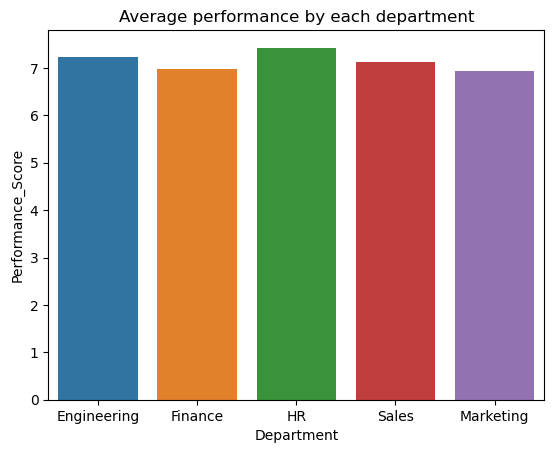

In [6]:
sns.barplot(data = df, x = 'Department', y = 'Performance_Score', errorbar=None)
plt.title("Average performance by each department")
plt.show()

In [7]:
# Calculate the average performance score for each department
avg_scores = df.groupby('Department')['Performance_Score'].mean()

# print results in formatted text using loop
for dept, score in avg_scores.items():
    print(f"{dept} average performance score is {score:.2f}")

Engineering average performance score is 7.22
Finance average performance score is 6.98
HR average performance score is 7.43
Marketing average performance score is 6.93
Sales average performance score is 7.13


In [8]:
avg_scores

Department
Engineering    7.223077
Finance        6.978947
HR             7.426667
Marketing      6.934375
Sales          7.125610
Name: Performance_Score, dtype: float64

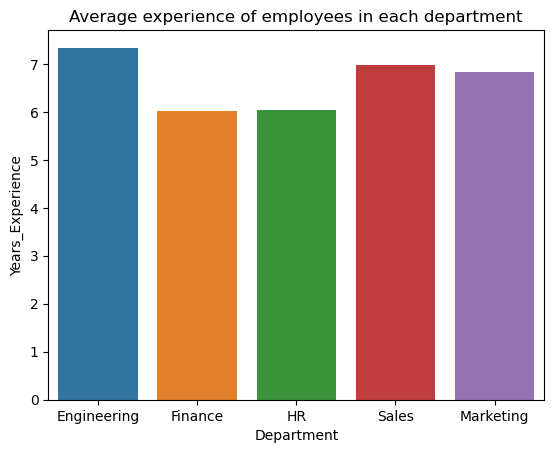

In [9]:
sns.barplot(data = df, x = 'Department', y = 'Years_Experience', errorbar=None)
plt.title("Average experience of employees in each department")
plt.show()

In [10]:
# Calculate the average performance score for each department
avg_performance = df.groupby('Department')['Years_Experience'].mean()

# print results in formatted text using loop
for dept, performance in avg_performance.items():
    print(f"{dept} average experience employees is {performance:.2f}")

Engineering average experience employees is 7.34
Finance average experience employees is 6.03
HR average experience employees is 6.03
Marketing average experience employees is 6.83
Sales average experience employees is 6.98


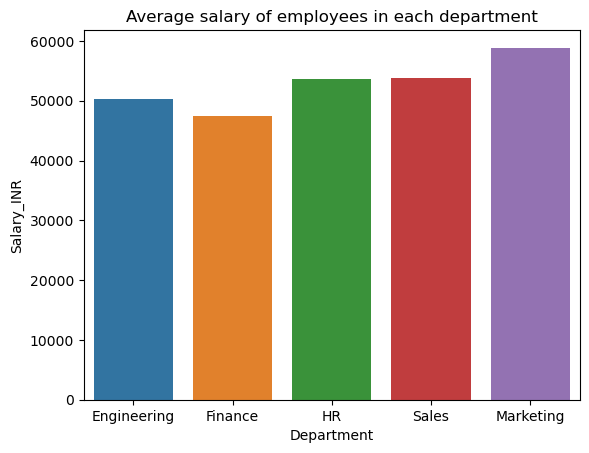

In [11]:
sns.barplot(data = df, x = 'Department', y = 'Salary_INR', errorbar=None)
plt.title("Average salary of employees in each department")
plt.show()

In [12]:
# Calculate the average performance score for each department
avg_salary = df.groupby('Department')['Salary_INR'].mean()

# print results in formatted text using loop
for dept, salary in avg_salary.items():
    print(f"{dept} department average salary is {salary:.2f}")

Engineering department average salary is 50378.13
Finance department average salary is 47509.84
HR department average salary is 53573.33
Marketing department average salary is 58871.88
Sales department average salary is 53799.40


In [13]:
# Calculate the average performance score for each department
avg_monthly_sales = df.groupby('Department')['Monthly_Sales_INR'].mean()

# print results in formatted text using loop
for dept, monthly_sales in avg_monthly_sales.items():
    print(f"{dept} average monthly sales is {monthly_sales:.2f}")

Engineering average monthly sales is 0.00
Finance average monthly sales is 0.00
HR average monthly sales is 0.00
Marketing average monthly sales is 0.00
Sales average monthly sales is 51041.46


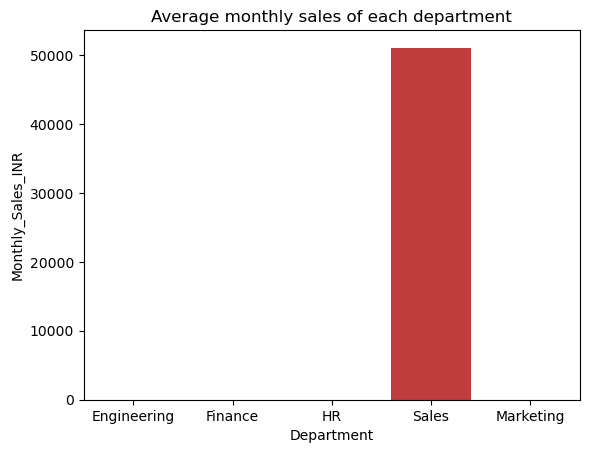

In [14]:
sns.barplot(data = df, x = 'Department', y = 'Monthly_Sales_INR', errorbar=None)
plt.title("Average monthly sales of each department")
plt.show()

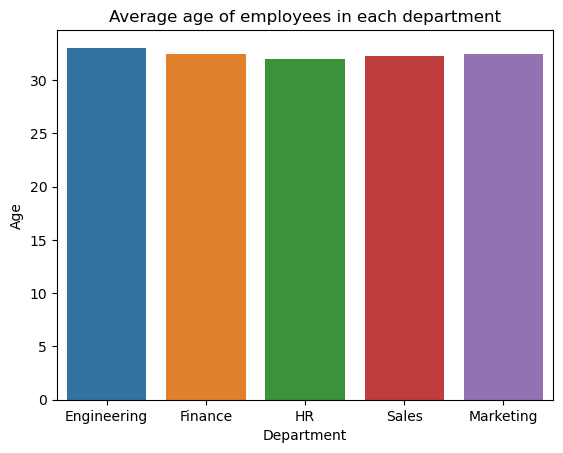

In [15]:
sns.barplot(data = df, x = 'Department', y = 'Age', errorbar=None)
plt.title("Average age of employees in each department")
plt.show()

In [16]:
# Calculate the average performance score for each department
avg_age = df.groupby('Department')['Age'].mean()

# print results in formatted text using loop
for dept, age in avg_age.items():
    print(f"{dept} average age of employees is {age:.2f}")

Engineering average age of employees is 33.04
Finance average age of employees is 32.42
HR average age of employees is 31.93
Marketing average age of employees is 32.44
Sales average age of employees is 32.24


In [17]:
# final report
df.groupby('Department')[['Age','Years_Experience','Salary_INR','Performance_Score','Monthly_Sales_INR']].mean().round(2)

,Age,Years_Experience,Salary_INR,Performance_Score,Monthly_Sales_INR
Department,,,,,
Engineering,33.04,7.34,50378.13,7.22,0.00
Finance,32.42,6.03,47509.84,6.98,0.00
HR,31.93,6.03,53573.33,7.43,0.00
Marketing,32.44,6.83,58871.88,6.93,0.00
Sales,32.24,6.98,53799.40,7.13,51041.46


# Median

In [18]:
# Calculate the median age for each department
median_age = df.groupby('Department')['Age'].median()

# print results in formatted text using loop
for dept, age in median_age.items():
    print(f"{dept} median age of employees is {age:.2f}")

Engineering median age of employees is 33.50
Finance median age of employees is 33.00
HR median age of employees is 32.00
Marketing median age of employees is 32.00
Sales median age of employees is 33.00


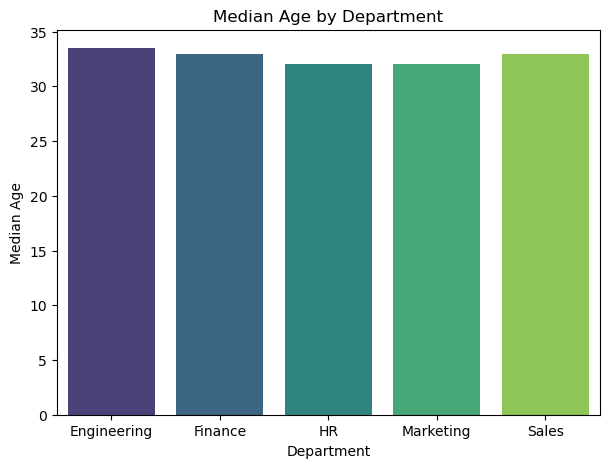

In [19]:
plt.figure(figsize=(7,5))
sns.barplot(x=median_age.index, y=median_age.values, palette='viridis')
plt.title('Median Age by Department')
plt.xlabel('Department')
plt.ylabel('Median Age')
plt.show()

In [20]:
# Calculate the median year of experience for each department
median_yoe = df.groupby('Department')['Years_Experience'].median()

# print results in formatted text using loop
for dept, age in median_yoe.items():
    print(f"{dept} median years of experience of employees is {age:.2f}")

Engineering median years of experience of employees is 6.20
Finance median years of experience of employees is 6.10
HR median years of experience of employees is 4.80
Marketing median years of experience of employees is 5.85
Sales median years of experience of employees is 5.80


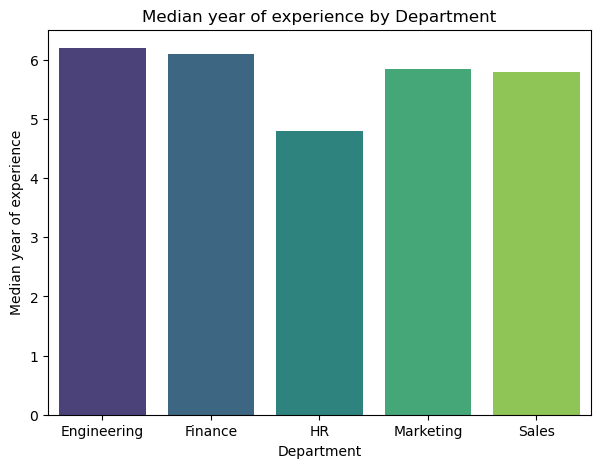

In [21]:
plt.figure(figsize=(7,5))
sns.barplot(x=median_yoe.index, y=median_yoe.values, palette='viridis')
plt.title('Median year of experience by Department')
plt.xlabel('Department')
plt.ylabel('Median year of experience')
plt.show()

In [22]:
# Calculate the median salary in each department
median_salary = df.groupby('Department')['Salary_INR'].median()

for dept, salary in median_salary.items():
    print(f"{dept} median salary of employees is {salary:.2f}")

Engineering median salary of employees is 44200.00
Finance median salary of employees is 43700.00
HR median salary of employees is 47900.00
Marketing median salary of employees is 59300.00
Sales median salary of employees is 50900.00


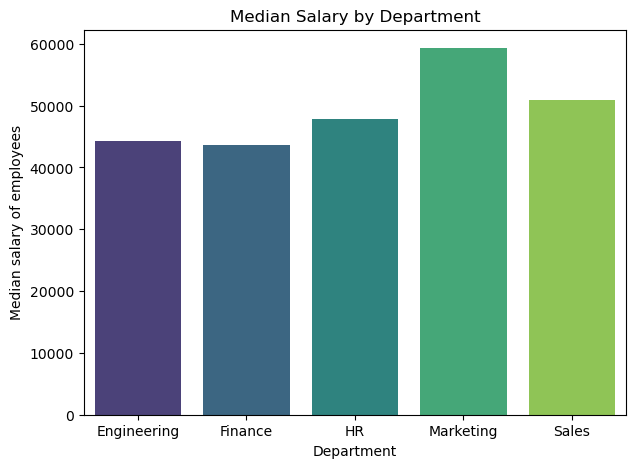

In [23]:
plt.figure(figsize=(7,5))
sns.barplot(x=median_salary.index, y=median_salary.values, palette='viridis')
plt.title('Median Salary by Department')
plt.xlabel('Department')
plt.ylabel('Median salary of employees')
plt.show()

In [24]:
# Calculate the median performance in each department
median_performance = df.groupby('Department')['Performance_Score'].median()

for dept, performance in median_performance.items():
    print(f"{dept} median salary of employees is {performance:.2f}")

Engineering median salary of employees is 7.30
Finance median salary of employees is 7.30
HR median salary of employees is 7.60
Marketing median salary of employees is 6.80
Sales median salary of employees is 7.20


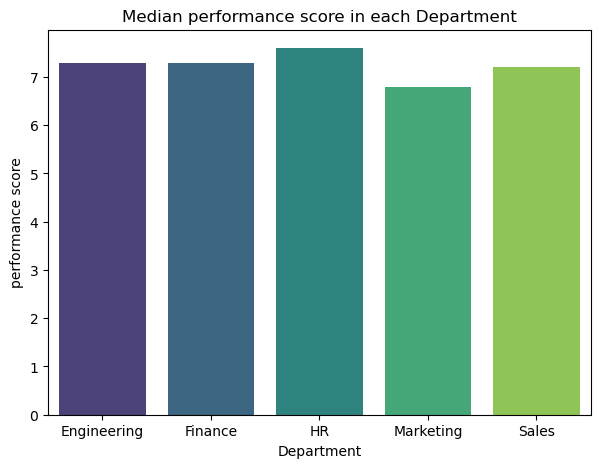

In [25]:
plt.figure(figsize=(7,5))
sns.barplot(x=median_performance.index, y=median_performance.values, palette='viridis')
plt.title('Median performance score in each Department')
plt.xlabel('Department')
plt.ylabel('performance score')
plt.show()

In [26]:
# Calculate the median performance in each department
median_sales = df.groupby('Department')['Monthly_Sales_INR'].median()

for dept, sales in median_sales.items():
    print(f"{dept} median sales of employees is {sales:.2f}")

Engineering median sales of employees is 0.00
Finance median sales of employees is 0.00
HR median sales of employees is 0.00
Marketing median sales of employees is 0.00
Sales median sales of employees is 50500.00


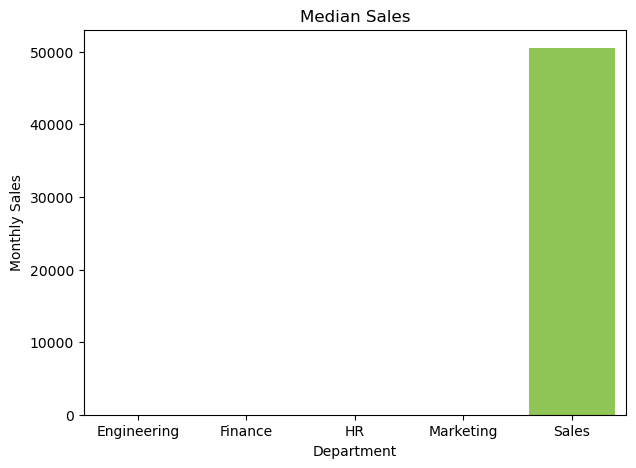

In [27]:
plt.figure(figsize=(7,5))
sns.barplot(x=median_sales.index, y=median_sales.values, palette='viridis')
plt.title('Median Sales')
plt.xlabel('Department')
plt.ylabel('Monthly Sales')
plt.show()

In [28]:
# final report
df.groupby('Department')[['Age','Years_Experience','Salary_INR','Performance_Score','Monthly_Sales_INR']].median().round(2)

,Age,Years_Experience,Salary_INR,Performance_Score,Monthly_Sales_INR
Department,,,,,
Engineering,33.5,6.20,44200.0,7.3,0.0
Finance,33.0,6.10,43700.0,7.3,0.0
HR,32.0,4.80,47900.0,7.6,0.0
Marketing,32.0,5.85,59300.0,6.8,0.0
Sales,33.0,5.80,50900.0,7.2,50500.0


## Mean vs Median Comparison

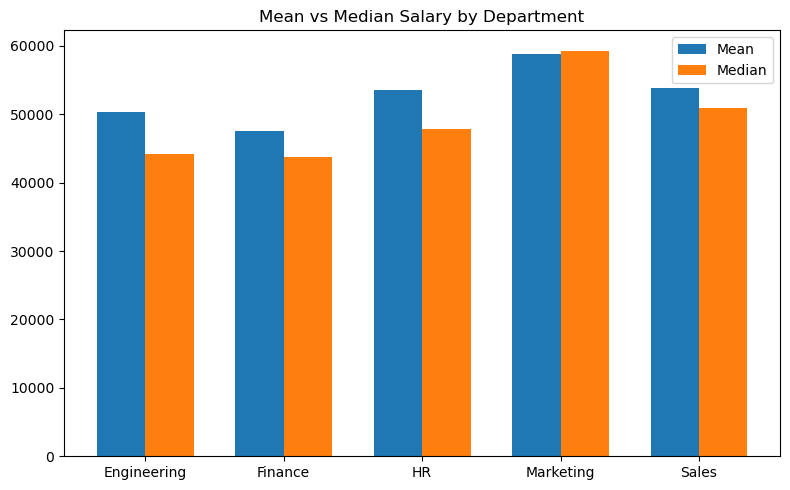

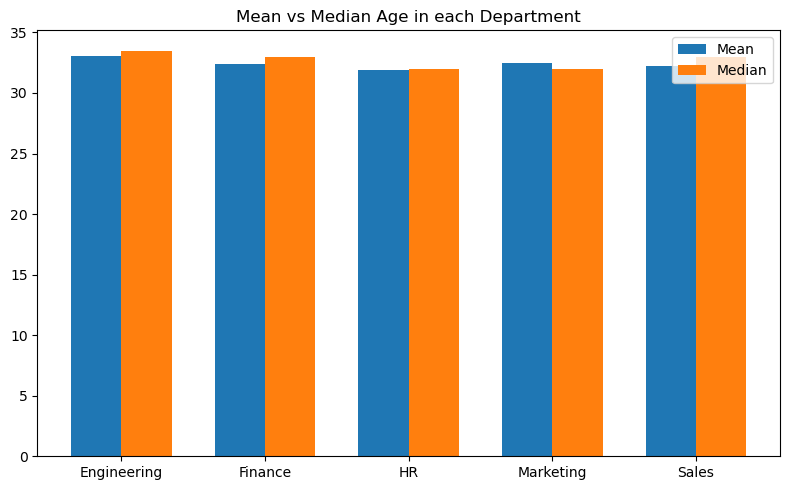

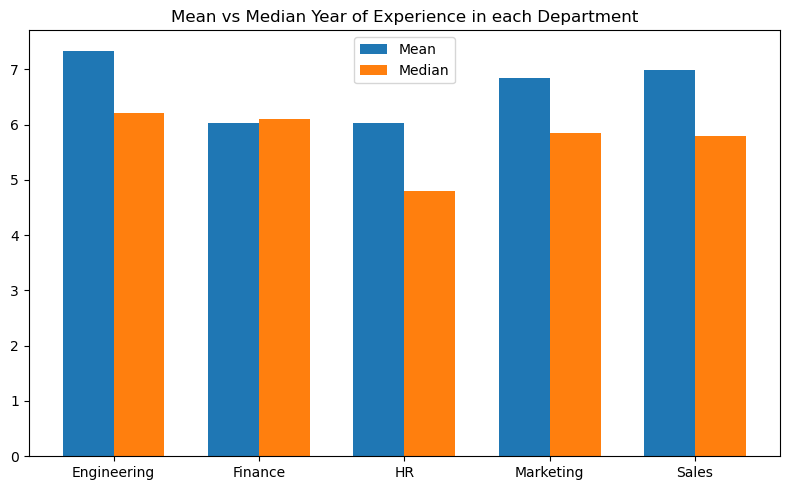

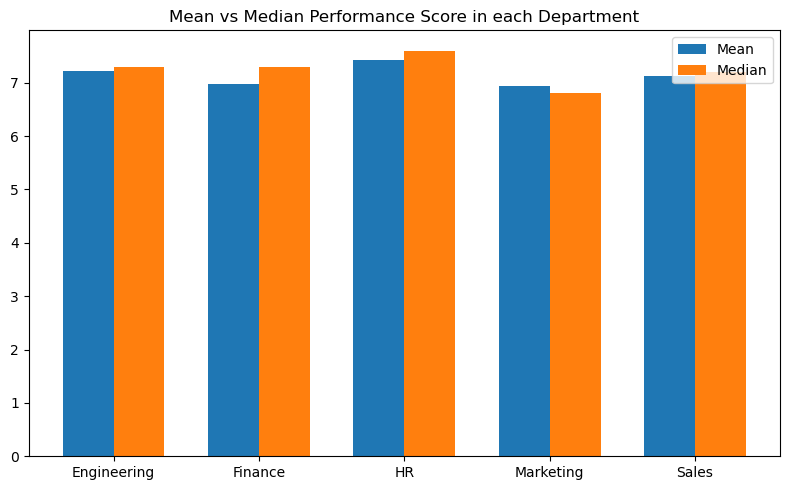

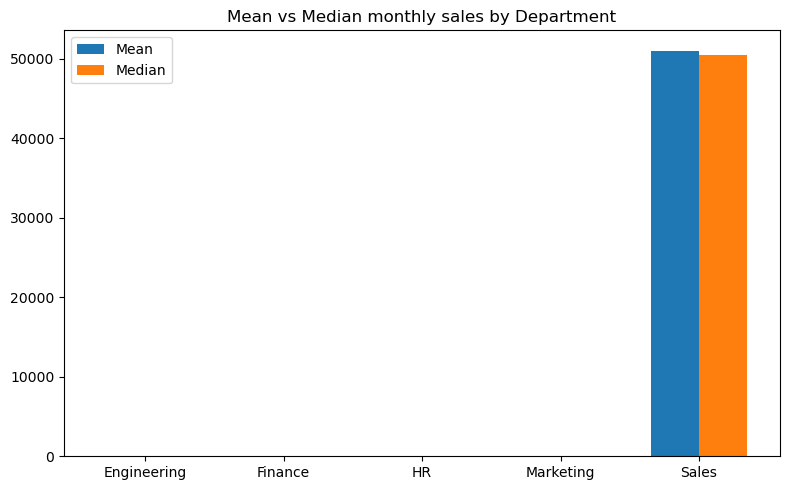

In [29]:
# Salary
mean_sal = df.groupby('Department')['Salary_INR'].mean()
median_sal = df.groupby('Department')['Salary_INR'].median()

x = np.arange(len(mean_sal.index))
width = 0.35

fig, ax = plt.subplots(figsize=(8,5))
ax.bar(x - width/2, mean_sal.values, width, label='Mean')
ax.bar(x + width/2, median_sal.values, width, label='Median')
ax.set_xticks(x)
ax.set_xticklabels(mean_sal.index)
ax.set_title('Mean vs Median Salary by Department')
ax.legend()
plt.tight_layout()
plt.show()

# Age
mean_age = df.groupby('Department')['Age'].mean()
median_age = df.groupby('Department')['Age'].median()

x = np.arange(len(mean_sal.index))
width = 0.35

fig, ax = plt.subplots(figsize=(8,5))
ax.bar(x - width/2, mean_age.values, width, label='Mean')
ax.bar(x + width/2, median_age.values, width, label='Median')
ax.set_xticks(x)
ax.set_xticklabels(mean_age.index)
ax.set_title('Mean vs Median Age in each Department')
ax.legend()
plt.tight_layout()
plt.show()

# Year of experience
mean_yoe = df.groupby('Department')['Years_Experience'].mean()
median_yoe = df.groupby('Department')['Years_Experience'].median()

x = np.arange(len(mean_sal.index))
width = 0.35

fig, ax = plt.subplots(figsize=(8,5))
ax.bar(x - width/2, mean_yoe.values, width, label='Mean')
ax.bar(x + width/2, median_yoe.values, width, label='Median')
ax.set_xticks(x)
ax.set_xticklabels(mean_yoe.index)
ax.set_title('Mean vs Median Year of Experience in each Department')
ax.legend()
plt.tight_layout()
plt.show()

# Performance Score
mean_performance = df.groupby('Department')['Performance_Score'].mean()
median_performance = df.groupby('Department')['Performance_Score'].median()

x = np.arange(len(mean_performance.index))
width = 0.35

fig, ax = plt.subplots(figsize=(8,5))
ax.bar(x - width/2, mean_performance.values, width, label='Mean')
ax.bar(x + width/2, median_performance.values, width, label='Median')
ax.set_xticks(x)
ax.set_xticklabels(mean_performance.index)
ax.set_title('Mean vs Median Performance Score in each Department')
ax.legend()
plt.tight_layout()
plt.show()

# Monthly Sales
mean_monthly_sales = df.groupby('Department')['Monthly_Sales_INR'].mean()
median_monthly_sales = df.groupby('Department')['Monthly_Sales_INR'].median()

x = np.arange(len(mean_monthly_sales.index))
width = 0.35

fig, ax = plt.subplots(figsize=(8,5))
ax.bar(x - width/2, mean_monthly_sales.values, width, label='Mean')
ax.bar(x + width/2, median_monthly_sales.values, width, label='Median')
ax.set_xticks(x)
ax.set_xticklabels(mean_monthly_sales.index)
ax.set_title('Mean vs Median monthly sales by Department')
ax.legend()
plt.tight_layout()
plt.show()

In [30]:
print("\nMean Report")
display(df.groupby('Department')[['Age','Years_Experience','Salary_INR','Performance_Score','Monthly_Sales_INR']].mean().round(2))

print("\nMedian Report")
display(df.groupby('Department')[['Age','Years_Experience','Salary_INR','Performance_Score','Monthly_Sales_INR']].median().round(2))


Mean Report


,Age,Years_Experience,Salary_INR,Performance_Score,Monthly_Sales_INR
Department,,,,,
Engineering,33.04,7.34,50378.13,7.22,0.00
Finance,32.42,6.03,47509.84,6.98,0.00
HR,31.93,6.03,53573.33,7.43,0.00
Marketing,32.44,6.83,58871.88,6.93,0.00
Sales,32.24,6.98,53799.40,7.13,51041.46



Median Report


,Age,Years_Experience,Salary_INR,Performance_Score,Monthly_Sales_INR
Department,,,,,
Engineering,33.5,6.20,44200.0,7.3,0.0
Finance,33.0,6.10,43700.0,7.3,0.0
HR,32.0,4.80,47900.0,7.6,0.0
Marketing,32.0,5.85,59300.0,6.8,0.0
Sales,33.0,5.80,50900.0,7.2,50500.0


# Mode

In [31]:
# Mode of Department
dept_mode = df['Department'].mode()[0]
print(f"Mode of Department: {dept_mode}")

# Mode of Age
age_mode = df['Age'].mode()[0]
print(f"Mode of Age: {age_mode}")

# Mode of Performance_Score
perf_mode = df['Performance_Score'].mode()[0]
print(f"Mode of Performance_Score: {perf_mode}")

Mode of Department: Sales
Mode of Age: 36
Mode of Performance_Score: 6.3


# Measures of Dispersion/Spread
* Range (max − min)
* Variance
* Standard deviation
* Interquartile Range (IQR)

In [32]:
numeric_cols = ['Age', 'Years_Experience', 'Salary_INR', 'Performance_Score', 'Monthly_Sales_INR']

for col in numeric_cols:
    data = df[col]
    
    rng = data.max() - data.min()          # Range
    variance = data.var()                   # Variance
    std_dev = data.std()                    # Standard Deviation
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1                           # IQR

    print(f"--- {col} ---")
    print(f"Range: {rng:.2f}")
    print(f"Variance: {variance:.2f}")
    print(f"Standard Deviation: {std_dev:.2f}")
    print(f"IQR: {iqr:.2f}")
    print()

--- Age ---
Range: 34.00
Variance: 32.54
Standard Deviation: 5.70
IQR: 8.00

--- Years_Experience ---
Range: 25.00
Variance: 17.99
Standard Deviation: 4.24
IQR: 5.95

--- Salary_INR ---
Range: 197305.00
Variance: 555545971.18
Standard Deviation: 23570.02
IQR: 22850.00

--- Performance_Score ---
Range: 8.10
Variance: 1.94
Standard Deviation: 1.39
IQR: 1.70

--- Monthly_Sales_INR ---
Range: 86800.00
Variance: 725094644.22
Standard Deviation: 26927.58
IQR: 46350.00



# Measures of Shape
* Skewness
* Kurtosis

In [34]:
cols = ['Age', 'Years_Experience', 'Salary_INR', 'Performance_Score']
for col in cols:
    skew = df[col].skew()
    kurt = df[col].kurt()
    print(f"{col}:Skewness = {skew:2f}, Kurtosis = {kurt:2f}")
    
# checking monthly sales skewness and kurtosis
sales = df[df['Department'] == 'Sales']['Monthly_Sales_INR']
skew_sales = sales.skew()
kurt_sales = sales.kurt()
print(f"Monthly_Sales_INR (Sales only): Skewness = {skew_sales:.2f}, Kurtosis = {kurt_sales:.2f}")

Age:Skewness = 0.446767, Kurtosis = 0.602839
Years_Experience:Skewness = 0.921061, Kurtosis = 0.932775
Salary_INR:Skewness = 2.560045, Kurtosis = 12.420617
Performance_Score:Skewness = -0.638458, Kurtosis = 1.501095
Monthly_Sales_INR (Sales only): Skewness = 0.13, Kurtosis = -0.76


C:\Users\dell\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\dell\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\dell\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\dell\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating ins

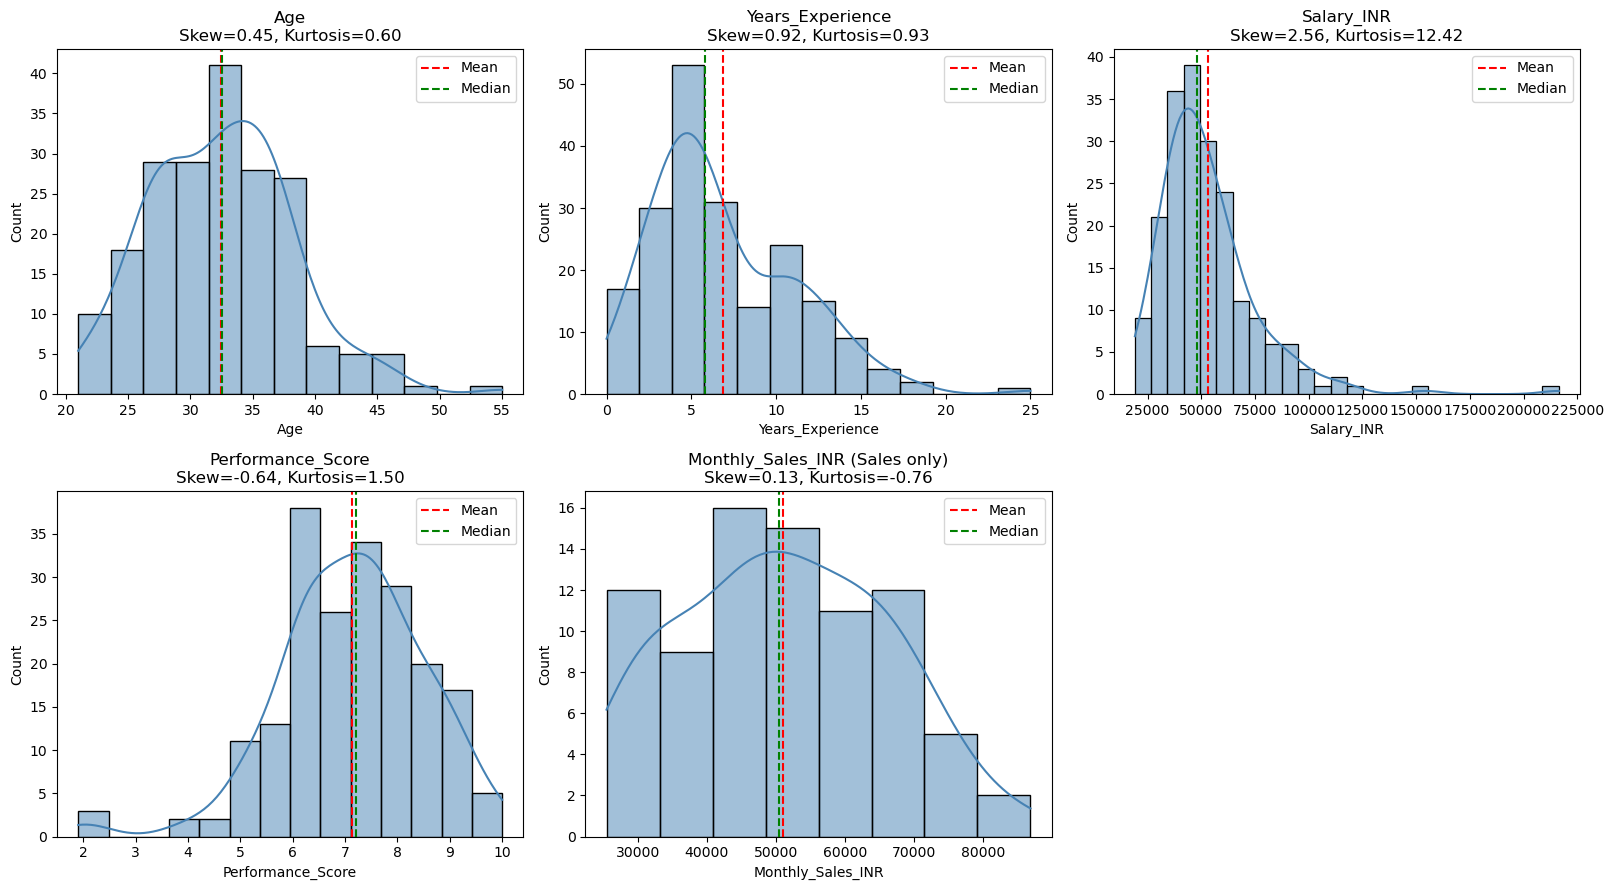

In [36]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

plots = [
    ('Age', df['Age'], axes[0]),
    ('Years_Experience', df['Years_Experience'], axes[1]),
    ('Salary_INR', df['Salary_INR'], axes[2]),
    ('Performance_Score', df['Performance_Score'], axes[3]),
    ('Monthly_Sales_INR (Sales only)', sales, axes[4]),
]

for title, data, ax in plots:
    sns.histplot(data, kde=True, color='steelblue', ax=ax)
    skew, kurt = data.skew(), data.kurt()
    ax.set_title(f'{title}\nSkew={skew:.2f}, Kurtosis={kurt:.2f}')
    ax.axvline(data.mean(), color='red', linestyle='--', label='Mean')
    ax.axvline(data.median(), color='green', linestyle='--', label='Median')
    ax.legend()

axes[5].axis('off')
plt.tight_layout()
plt.show()

# Position/Relative Standing
* Percentiles and quantiles (e.g., 90th percentile)
* Z-scores (how many SDs a point is from the mean)

In [37]:
cols = ['Age', 'Years_Experience', 'Salary_INR', 'Performance_Score']

# --- Percentiles / Quantiles ---
for col in cols:
    p25 = df[col].quantile(0.25)
    p50 = df[col].quantile(0.50)
    p75 = df[col].quantile(0.75)
    p90 = df[col].quantile(0.90)
    print(f"{col}: 25th={p25:.2f}, 50th={p50:.2f}, 75th={p75:.2f}, 90th={p90:.2f}")

# --- Z-scores ---
df['Salary_zscore'] = stats.zscore(df['Salary_INR'])
print(df[['Employee_ID', 'Salary_INR', 'Salary_zscore']].head())

Age: 25th=28.00, 50th=32.50, 75th=36.00, 90th=39.00
Years_Experience: 25th=3.98, 50th=5.80, 75th=9.93, 90th=12.64
Salary_INR: 25th=38975.00, 50th=48150.00, 75th=61825.00, 90th=81360.00
Performance_Score: 25th=6.30, 50th=7.20, 75th=8.00, 90th=8.90
  Employee_ID  Salary_INR  Salary_zscore
0      EMP001       83500       1.292713
1      EMP002       59200       0.259155
2      EMP003       34100      -0.808429
3      EMP004       45900      -0.306537
4      EMP005       36100      -0.723363


In [38]:
df

,Employee_ID,Department,Age,Years_Experience,Salary_INR,Performance_Score,Monthly_Sales_INR,Salary_zscore
0,EMP001,Engineering,28,3.9,83500,8.9,0,1.292713
1,EMP002,Finance,33,10.1,59200,7.3,0,0.259155
2,EMP003,HR,34,4.8,34100,8.3,0,-0.808429
3,EMP004,Engineering,28,4.2,45900,5.1,0,-0.306537
4,EMP005,Sales,43,6.7,36100,7.3,45000,-0.723363
...,...,...,...,...,...,...,...,...
195,EMP196,Sales,24,2.1,57300,7.8,65000,0.178342
196,EMP197,HR,28,5.4,43200,8.4,0,-0.421377
197,EMP198,Marketing,31,6.0,73600,6.3,0,0.871633
198,EMP199,Marketing,34,4.6,33600,8.7,0,-0.829696


In [44]:
df[['Employee_ID', 'Salary_INR', 'Salary_zscore']].head()

,Employee_ID,Salary_INR,Salary_zscore
0,EMP001,83500,1.292713
1,EMP002,59200,0.259155
2,EMP003,34100,-0.808429
3,EMP004,45900,-0.306537
4,EMP005,36100,-0.723363


I picked Salary_INR because it has the most dramatic outliers (the skew=2.56, kurtosis=12.42), so the Z-scores would look the most striking and easy to interpret. 

# Frequency Distribution
* Counting how often values/categories occur

In [45]:
freq_table = df['Department'].value_counts()
print(freq_table)

# As percentages
print((df['Department'].value_counts(normalize=True) * 100).round(2))

Department
Sales          82
Engineering    52
Marketing      32
Finance        19
HR             15
Name: count, dtype: int64
Department
Sales          41.0
Engineering    26.0
Marketing      16.0
Finance         9.5
HR              7.5
Name: proportion, dtype: float64


In [46]:
bins = [20, 30, 40, 50, 60]
labels = ['21-30', '31-40', '41-50', '51-60']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)
print(df['Age_Group'].value_counts().sort_index())

Age_Group
21-30     75
31-40    110
41-50     14
51-60      1
Name: count, dtype: int64


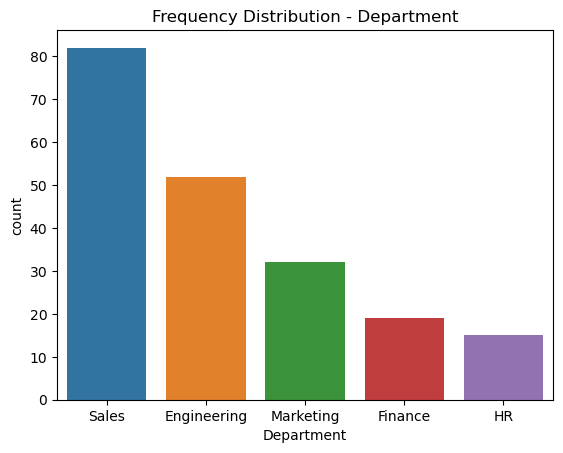

C:\Users\dell\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


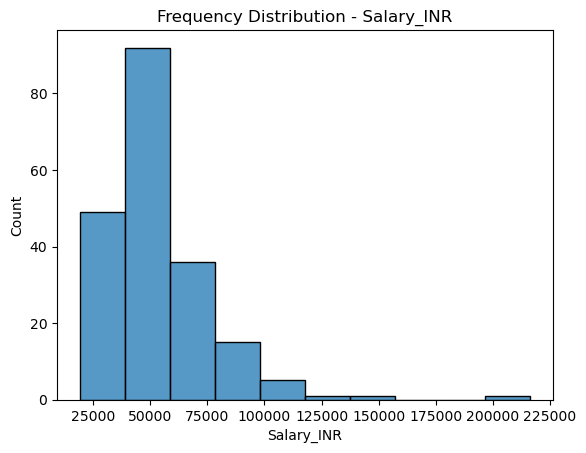

In [47]:
sns.countplot(data=df, x='Department', order=df['Department'].value_counts().index)
plt.title('Frequency Distribution - Department')
plt.show()

sns.histplot(df['Salary_INR'], bins=10)
plt.title('Frequency Distribution - Salary_INR')
plt.show()

# Visual Summaries (technically part of EDA, but tightly linked)
* Histograms, box plots, bar charts — visually show spread, central tendency, and outliers together

In [51]:
# Default - numeric columns only
print(df.describe())

              Age  Years_Experience     Salary_INR  Performance_Score  \
count  200.000000        200.000000     200.000000         200.000000   
mean    32.475000          6.887500   53107.005000           7.129000   
std      5.704567          4.241917   23570.022723           1.392932   
min     21.000000          0.000000   19100.000000           1.900000   
25%     28.000000          3.975000   38975.000000           6.300000   
50%     32.500000          5.800000   48150.000000           7.200000   
75%     36.000000          9.925000   61825.000000           8.000000   
max     55.000000         25.000000  216405.000000          10.000000   

       Monthly_Sales_INR  Salary_zscore  
count         200.000000   2.000000e+02  
mean        20927.000000   1.065814e-16  
std         26927.581477   1.002509e+00  
min             0.000000  -1.446428e+00  
25%             0.000000  -6.010799e-01  
50%             0.000000  -2.108375e-01  
75%         46350.000000   3.708046e-01  
max   

In [53]:
df

,Employee_ID,Department,Age,Years_Experience,Salary_INR,Performance_Score,Monthly_Sales_INR,Salary_zscore,Age_Group
0,EMP001,Engineering,28,3.9,83500,8.9,0,1.292713,21-30
1,EMP002,Finance,33,10.1,59200,7.3,0,0.259155,31-40
2,EMP003,HR,34,4.8,34100,8.3,0,-0.808429,31-40
3,EMP004,Engineering,28,4.2,45900,5.1,0,-0.306537,21-30
4,EMP005,Sales,43,6.7,36100,7.3,45000,-0.723363,41-50
...,...,...,...,...,...,...,...,...,...
195,EMP196,Sales,24,2.1,57300,7.8,65000,0.178342,21-30
196,EMP197,HR,28,5.4,43200,8.4,0,-0.421377,21-30
197,EMP198,Marketing,31,6.0,73600,6.3,0,0.871633,31-40
198,EMP199,Marketing,34,4.6,33600,8.7,0,-0.829696,31-40


In [54]:
cols = ['Age', 'Years_Experience', 'Salary_INR', 'Performance_Score']

for col in cols:
    data = df[col]
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr

    outliers_iqr = df[(data < lower) | (data > upper)][['Employee_ID', 'Department', col]]
    z = np.abs(stats.zscore(data))
    outliers_z = df[z > 3][['Employee_ID', 'Department', col]]

    print(f"{col}: IQR outliers = {len(outliers_iqr)}, Z-score outliers = {len(outliers_z)}")

Age: IQR outliers = 1, Z-score outliers = 1
Years_Experience: IQR outliers = 1, Z-score outliers = 1
Salary_INR: IQR outliers = 8, Z-score outliers = 2
Performance_Score: IQR outliers = 3, Z-score outliers = 3
